In [36]:
import numpy as np
import matplotlib.pyplot
from scipy.stats import beta
from math import factorial
import scipy.integrate as integrate

# Q2

In [137]:
def beta(a,b,theta):
    '''
    The prior is the beta distribution function. a = heads, b = tails, theta = θ is the probability of getting a head
    '''
    coeff = factorial(a + b - 1)/(factorial(a - 1)*factorial(b - 1))
    return coeff*theta**(a - 1)*(1 - theta)**(b - 1)

def binomial(n,h,theta):
    '''
    The likelihood function is the binomial distribution. n = total number of coin flips, h is the number of heads, theta is the probability
    of getting a head. 
    '''
    denom = factorial(h)*factorial(n-h)
    return factorial(n)/denom * theta**h * (1 - theta)**(n - h)

def make_prior(a, b):
    '''
    The prior function, since theta needs to be swept (not a direct input), I'm defining the "main" function inside 
    '''
    def prior(theta):
        return beta(a,b,theta)
    return prior

def make_likelihood(n, h):
    '''
    The likelihood function, since theta needs to be swept (not a direct input), I'm defining the "main" function inside 
    '''
    def likelihood(theta):
        return binomial(n,h,theta)
    return likelihood

def make_posterior(prior, likelihood):

    def unnormalized(theta):
        return prior(theta) * likelihood(theta)

    normalization, _ = integrate.quad(unnormalized, 0, 1) #returns (value, error) - only need value

    def posterior(theta):
        return unnormalized(theta) / normalization
    return posterior

def Bayes(dataname,a,b):
    '''
    This is the function asked for in Q2a since it outputs the posterior probability distribution function.
    '''
    if isinstance(dataname, str):
        data = np.loadtxt(dataname)
    else:
        data = dataname
    
    n = len(data) #number of coin flips
    h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)

    likelihood = make_likelihood(n, h)
    prior = make_prior(a, b) 
    posterior = make_posterior(prior, likelihood)

    return posterior

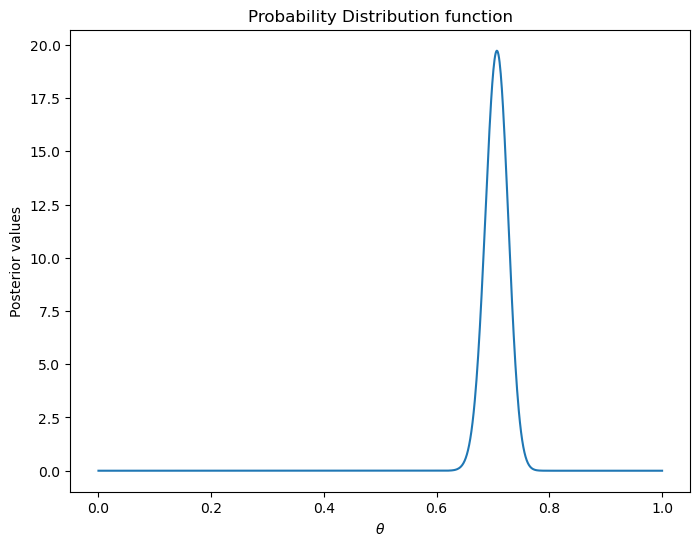

In [138]:
posterior = Bayes("HW06_data.txt",2,5)

thetas = np.linspace(0,1,1000) #test over different values of theta
p_vals = np.array([posterior(t) for t in thetas])

plt.figure(figsize=(8,6))
plt.plot(thetas,p_vals)
plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.show()

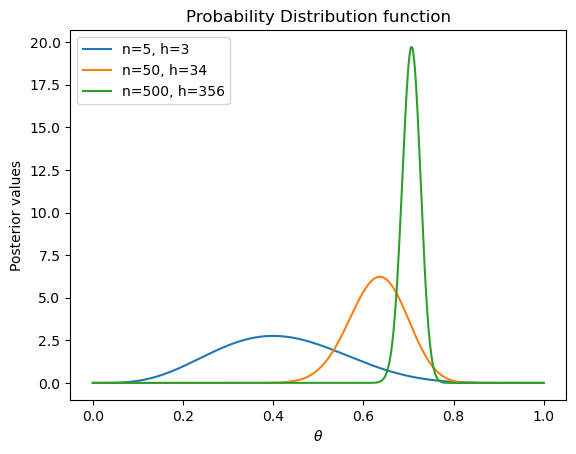

In [83]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
prior = make_prior(2, 5) 
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

## d

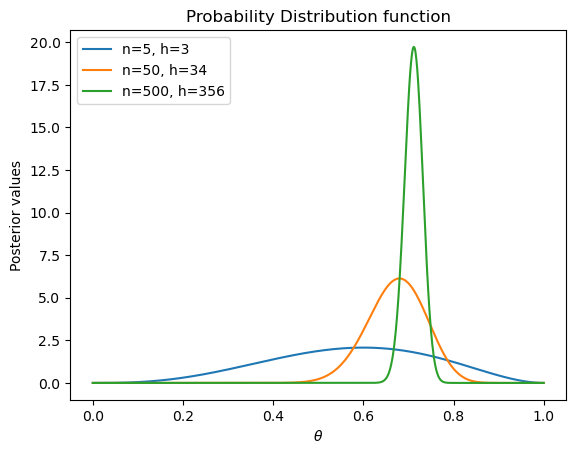

In [102]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(1, 1) #flat - no idea if coin is fair
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

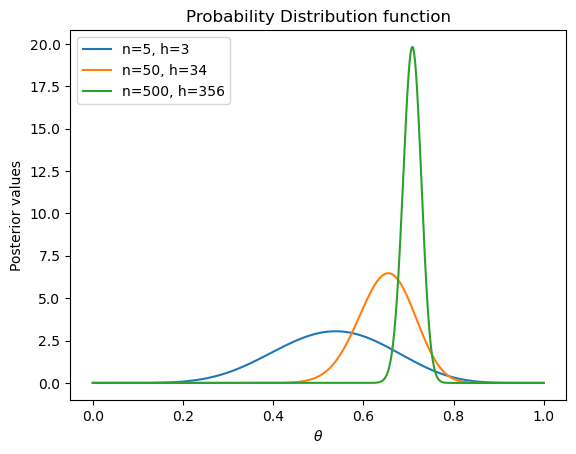

In [103]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(5, 5) #roughly fair coin
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

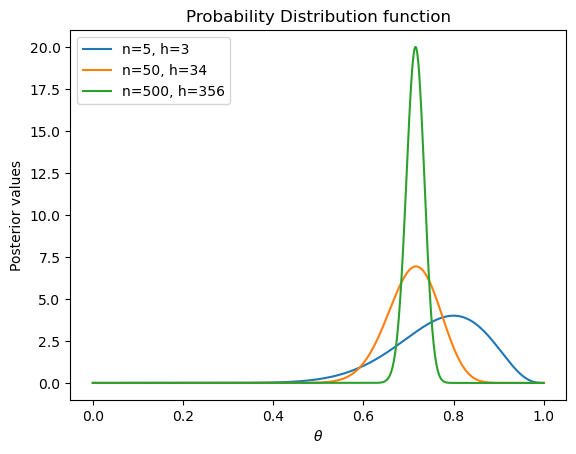

In [104]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(10, 2) #strong belief coin biased towards heads
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

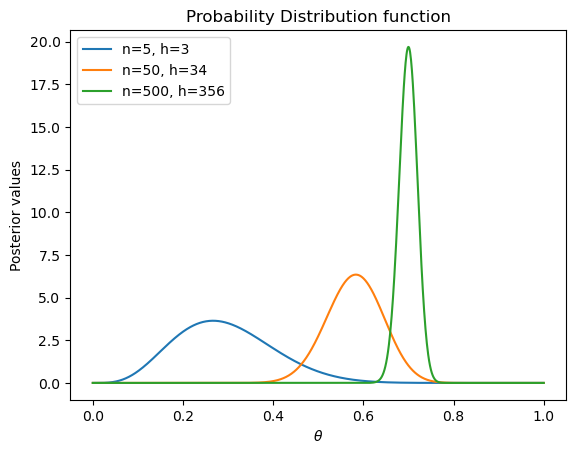

In [105]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(2, 10) #strong belief coin biased towards tails
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

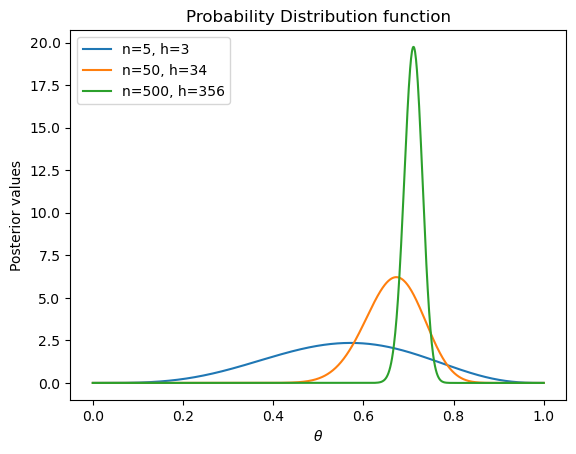

In [106]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(2, 2) #weak belief in fairness - open to be wrong
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

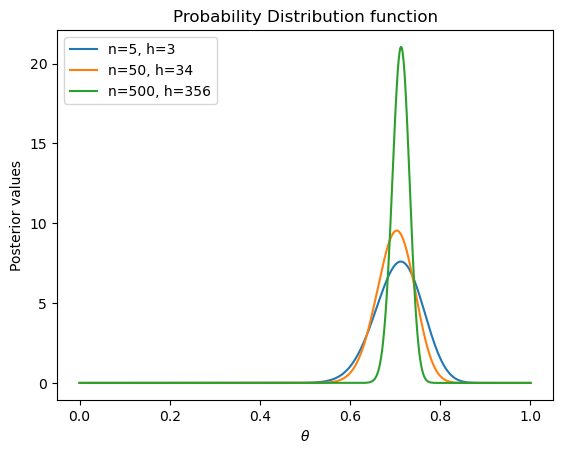

In [107]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(50,20) #weak belief in fairness - open to be wrong
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

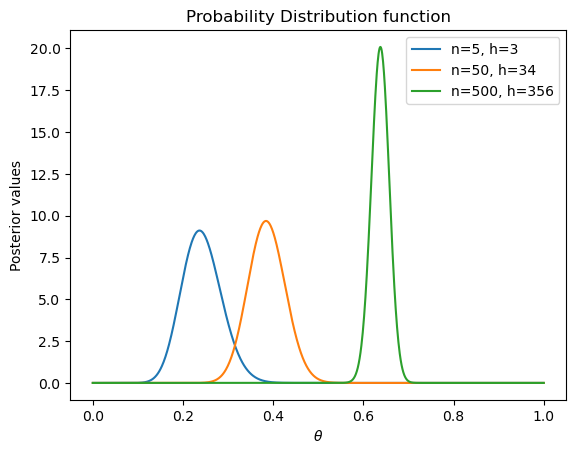

In [109]:
data = np.loadtxt("HW06_data.txt")
n = [5,50,500]
h = int(np.sum(data)) #number of heads, so 0 = tails, 1 = heads (want to add up all the heads)
prior = make_prior(20,70) #weak belief in fairness - open to be wrong
thetas = np.linspace(0,1,1000) #test over different values of theta

for coin_flips in n:
    h = int(np.sum(data[:coin_flips]))
    likelihood = make_likelihood(coin_flips, h)
    posterior = make_posterior(prior, likelihood)
    p_vals = np.array([posterior(t) for t in thetas])

    plt.plot(thetas, p_vals, label=f"n={coin_flips}, h={h}")

plt.xlabel(r"$\theta$")
plt.ylabel("Posterior values")
plt.title("Probability Distribution function")
plt.legend()
plt.show()

# Q3

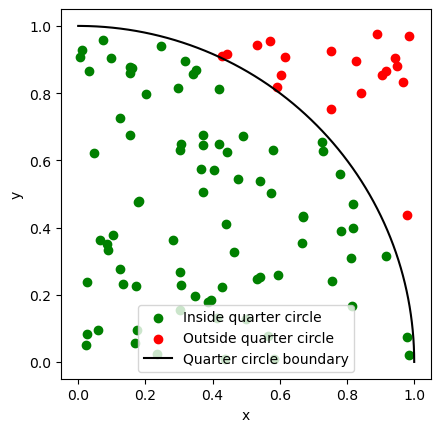

In [155]:
N = 100 #number of points
x = np.random.uniform(0, 1, N)
y = np.random.uniform(0, 1, N)

inside = (x**2+y**2) <= 1
h = np.sum(inside)

plt.scatter(x[inside], y[inside], color="green",label="Inside quarter circle")
plt.scatter(x[~inside], y[~inside], color="red",label="Outside quarter circle")

# quarter circle boundary
theta = np.linspace(0, np.pi/2, 200)
plt.plot(np.cos(theta), np.sin(theta), color="black",label="Quarter circle boundary")


plt.xlabel("x")
plt.ylabel("y")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
#plt.show()

In [140]:
post = Bayes(inside,2,3)